# Heart Disease Prediction

## Objective

Predict the presence of heart disease from patient clinical data, comparing a Decision Tree, a Random Forest, and an XGBoost classifier, including hyperparameter tuning for each.


## Step 1: Import Libraries


In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

## Step 2: Load & Explore Data


In [136]:
df = pd.read_csv("heart.csv")
df.head(30)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [138]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [139]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [140]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


## Step 3: Data Preprocessing


In [141]:
Catagorical = ['cp','restecg','slope','thal']

df = pd.get_dummies(df,columns =Catagorical,dtype = int )

df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,...,restecg_0,restecg_1,restecg_2,slope_0,slope_1,slope_2,thal_0,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,0,...,0,1,0,0,0,1,0,0,0,1
1,53,1,140,203,1,155,1,3.1,0,0,...,1,0,0,1,0,0,0,0,0,1
2,70,1,145,174,0,125,1,2.6,0,0,...,0,1,0,1,0,0,0,0,0,1
3,61,1,148,203,0,161,0,0.0,1,0,...,0,1,0,0,0,1,0,0,0,1
4,62,0,138,294,1,106,0,1.9,3,0,...,0,1,0,0,1,0,0,0,1,0


In [142]:
features = [x for x in df.columns if x not in 'target']
print(len(features))


23


## Step 4: Train/Test Split


In [143]:
x_train , x_test , y_train , y_test = train_test_split(df[features],df['target'],train_size = 0.8,random_state = 52)

## Step 5: Decision Tree - Hyperparameter Tuning


In [144]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None] 

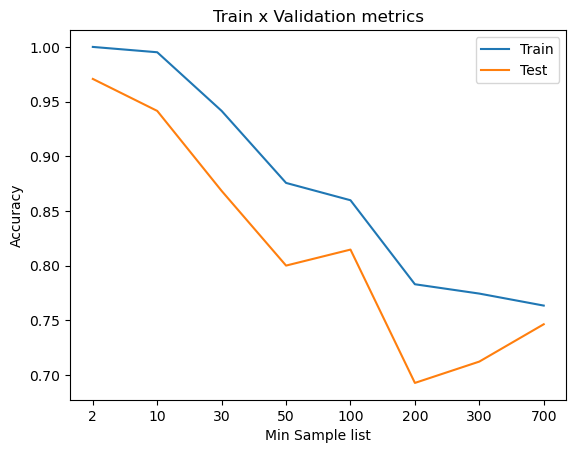

In [145]:
accuracy_train = []
accuracy_test = []

for i in min_samples_split_list:
    model = DecisionTreeClassifier(min_samples_split = i,random_state = 52)
    model.fit(x_train,y_train)

    predict_train = model.predict(x_train)
    predict_test = model.predict(x_test)

    acc_train = accuracy_score(predict_train,y_train)
    acc_test = accuracy_score(predict_test,y_test)

    accuracy_train.append(acc_train)
    accuracy_test.append(acc_test)

plt.title('Train x Validation metrics')
plt.xlabel('Min Sample list')
plt.ylabel('Accuracy')
plt.plot(accuracy_train)
plt.plot(accuracy_test)
plt.xticks(ticks = range(len(min_samples_split_list)) , labels = min_samples_split_list)
plt.legend(['Train','Test'])

    

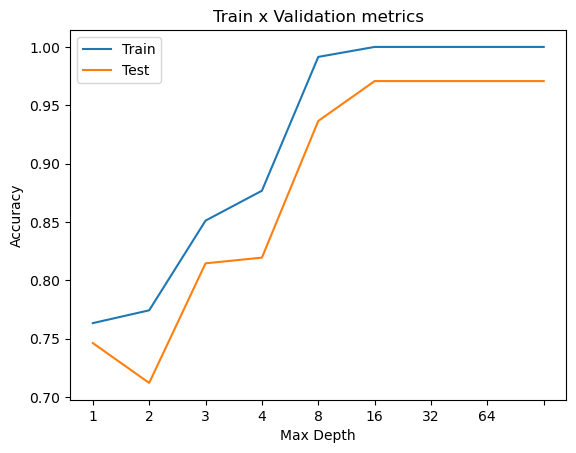

In [146]:
accuracy_train = []
accuracy_test = []

for i in max_depth_list:
    model = DecisionTreeClassifier(max_depth = i,random_state = 52)
    model.fit(x_train,y_train)

    predict_train = model.predict(x_train)
    predict_test = model.predict(x_test)

    acc_train = accuracy_score(predict_train,y_train)
    acc_test = accuracy_score(predict_test,y_test)

    accuracy_train.append(acc_train)
    accuracy_test.append(acc_test)

plt.title('Train x Validation metrics')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.plot(accuracy_train)
plt.plot(accuracy_test)
plt.xticks(ticks = range(len(max_depth_list)) , labels = max_depth_list)
plt.legend(['Train','Test'])


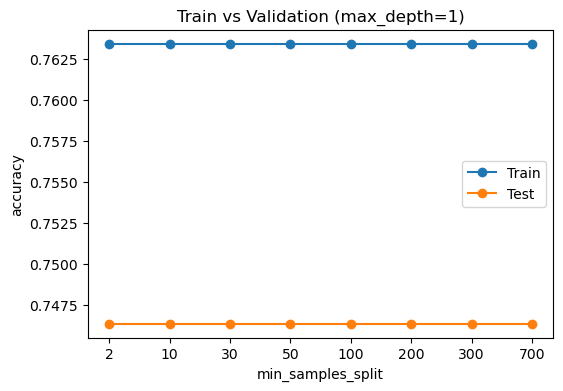

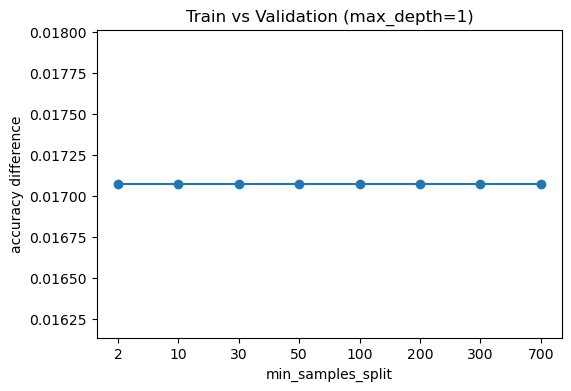

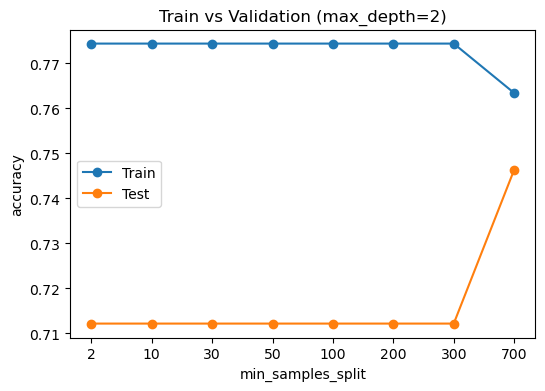

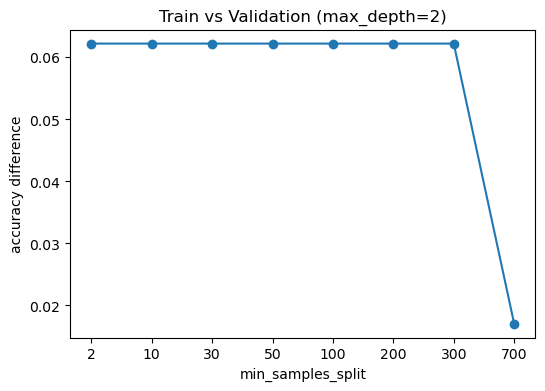

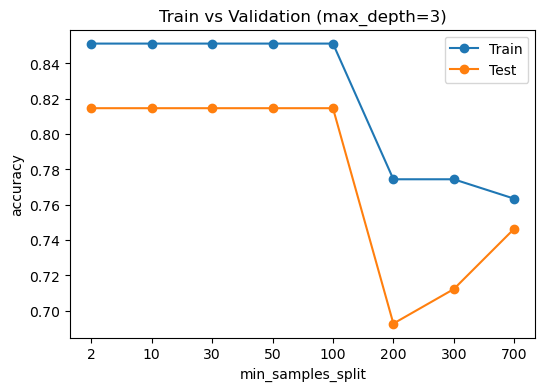

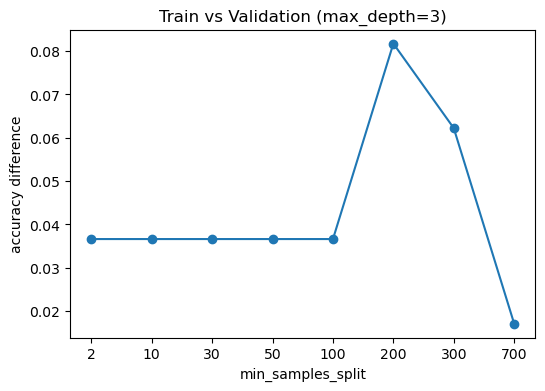

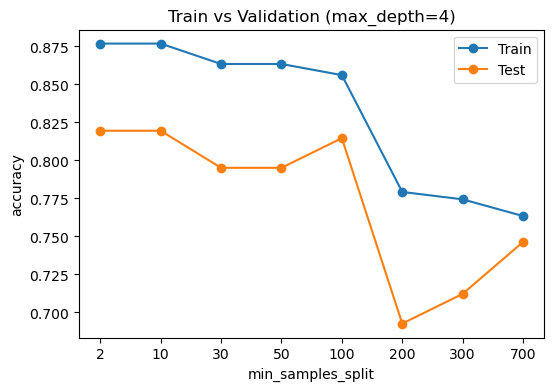

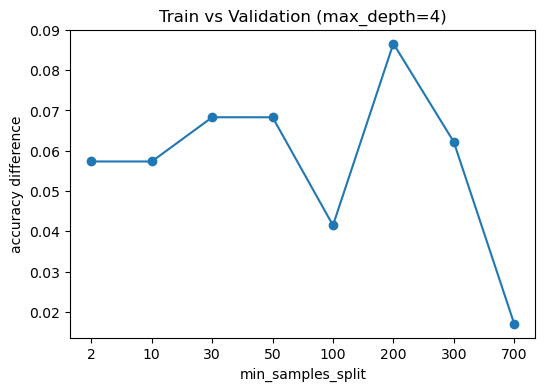

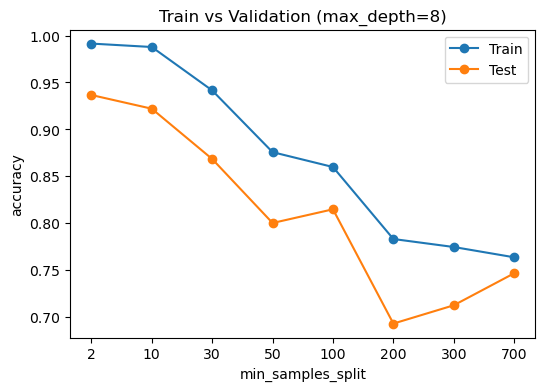

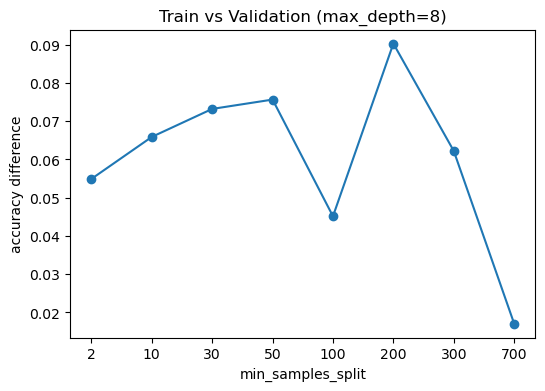

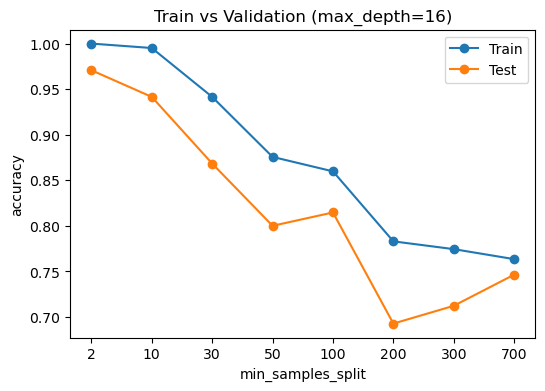

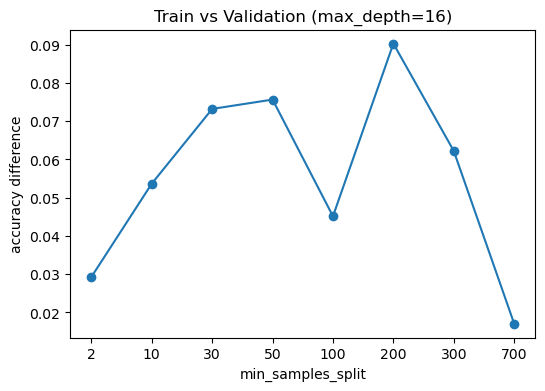

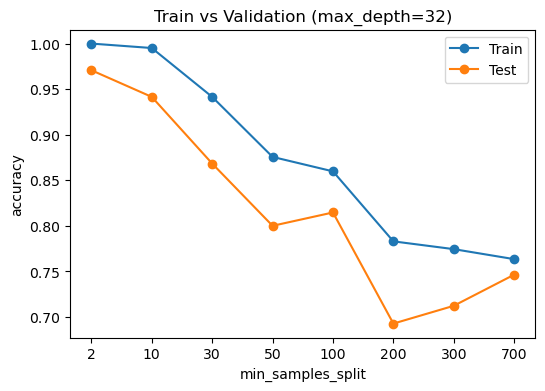

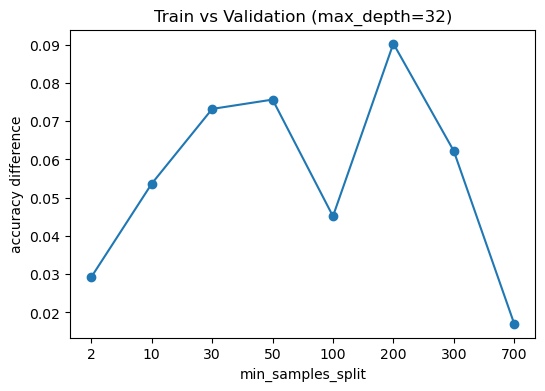

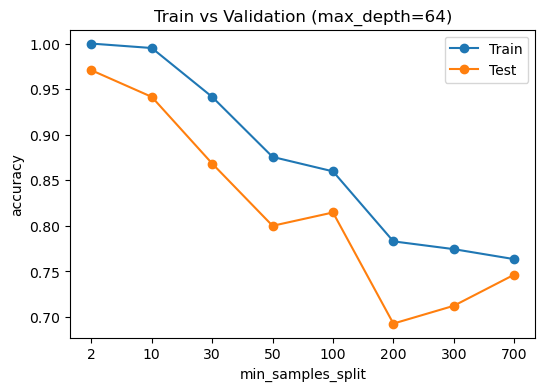

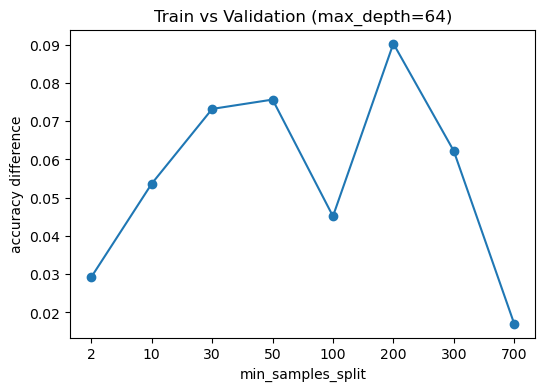

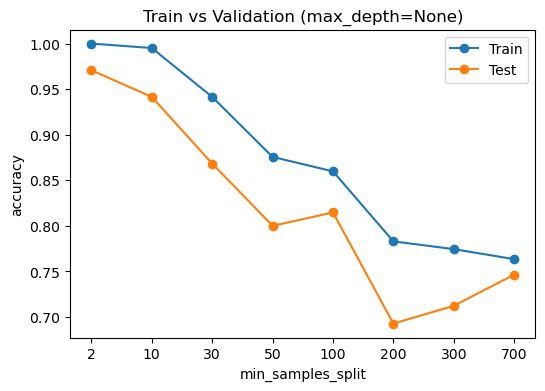

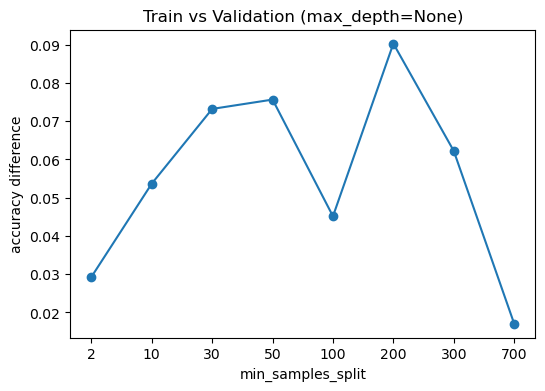

In [147]:
for j in max_depth_list:
    accuracy_train = []
    accuracy_test = []
    
    for i in min_samples_split_list:
        model = DecisionTreeClassifier(min_samples_split=i, max_depth=j, random_state=52)
        model.fit(x_train, y_train)

        predict_train = model.predict(x_train)
        predict_test = model.predict(x_test)

        acc_train = accuracy_score(y_train, predict_train)
        acc_test = accuracy_score(y_test, predict_test)

        accuracy_train.append(acc_train)
        accuracy_test.append(acc_test)
    
    # Plot for this depth
    plt.figure(figsize=(6, 4))
    plt.title(f'Train vs Validation (max_depth={j})')
    plt.xlabel('min_samples_split')
    plt.ylabel('accuracy')
    plt.plot(accuracy_train, marker='o')
    plt.plot(accuracy_test, marker='o')
    plt.xticks(
        ticks=range(len(min_samples_split_list)),
        labels=min_samples_split_list
    )
    plt.legend(['Train', 'Test'])
    plt.show()
    
    plt.figure(figsize=(6, 4))
    plt.title(f'Train vs Validation (max_depth={j})')
    plt.xlabel('min_samples_split')
    plt.ylabel('accuracy difference')
    plt.plot(np.array(accuracy_train) -  np.array(accuracy_test), marker='o')
    plt.xticks(
        ticks=range(len(min_samples_split_list)),
        labels=min_samples_split_list
    )
    plt.show()
    
    

## Step 6: Decision Tree - Final Model


In [148]:
model = DecisionTreeClassifier(min_samples_split = 10,max_depth = 32,random_state = 52)
model.fit(x_train,y_train)
predict_train = model.predict(x_train)
predict_test = model.predict(x_test)

acc_train = accuracy_score(predict_train,y_train)
acc_test = accuracy_score(predict_test,y_test)

print(f"{acc_train}, {acc_test}")

0.9951219512195122, 0.9414634146341463


## Step 7: Random Forest - Hyperparameter Tuning


In [149]:
rf = RandomForestClassifier(random_state=52)
param_grid = {
    'n_estimators': [50, 100, 200],        # number of trees
    'max_depth': [4, 8, 16, 32],           # tree depth
    'min_samples_split': [2, 10, 30, 50]   # minimum samples to split
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',  # metric to optimize
    n_jobs=-1            # use all CPU cores
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)


Best Parameters: {'max_depth': 16, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy: 0.9914634146341463


## Step 8: Random Forest - Final Model


In [150]:
model = RandomForestClassifier(max_depth = 16,min_samples_split = 2,n_estimators = 200,random_state = 52)
model.fit(x_train,y_train)

predict_train = model.predict(x_train)
predict_test = model.predict(x_test)

acc_train = accuracy_score(predict_train,y_train)
acc_test = accuracy_score(predict_test,y_test)

print(acc_train)
print(acc_test)

1.0
0.9707317073170731


## Step 9: XGBoost - Train/Eval Split


In [151]:
n = int(len(x_train)*0.8) ## Let's use 80% to train and 20% to eval

In [152]:
X_train_fit, X_train_eval, y_train_fit, y_train_eval = x_train[:n], x_train[n:], y_train[:n], y_train[n:]

## Step 10: XGBoost - Model Training


In [153]:
xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1,verbosity = 1, random_state = 52)
xgb_model.fit(X_train_fit,y_train_fit, eval_set = [(X_train_eval,y_train_eval)])

[0]	validation_0-logloss:0.62706
[1]	validation_0-logloss:0.57332
[2]	validation_0-logloss:0.52790
[3]	validation_0-logloss:0.48434
[4]	validation_0-logloss:0.45078
[5]	validation_0-logloss:0.42178
[6]	validation_0-logloss:0.39249
[7]	validation_0-logloss:0.36521
[8]	validation_0-logloss:0.34403
[9]	validation_0-logloss:0.32184
[10]	validation_0-logloss:0.30422
[11]	validation_0-logloss:0.28875
[12]	validation_0-logloss:0.27370
[13]	validation_0-logloss:0.25980
[14]	validation_0-logloss:0.24731
[15]	validation_0-logloss:0.23499
[16]	validation_0-logloss:0.22434
[17]	validation_0-logloss:0.21428
[18]	validation_0-logloss:0.20711
[19]	validation_0-logloss:0.19872
[20]	validation_0-logloss:0.18981
[21]	validation_0-logloss:0.18327
[22]	validation_0-logloss:0.17749
[23]	validation_0-logloss:0.16936
[24]	validation_0-logloss:0.16365
[25]	validation_0-logloss:0.15852
[26]	validation_0-logloss:0.15331
[27]	validation_0-logloss:0.14660
[28]	validation_0-logloss:0.14288
[29]	validation_0-loglos

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Step 11: XGBoost - Final Metrics


In [154]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(xgb_model.predict(x_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(xgb_model.predict(x_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.9976
Metrics test:
	Accuracy score: 0.9659


## Step 12: Model Comparison


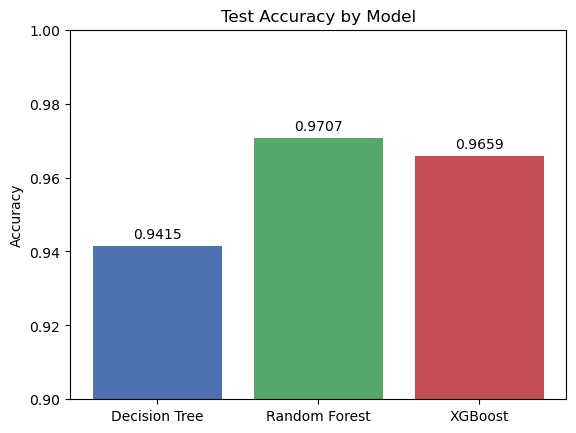

In [155]:
# test accuracy for each tuned model, taken from the runs above
results = {
    'Decision Tree': 0.9415,
    'Random Forest': 0.9707,
    'XGBoost': 0.9659,
}

plt.bar(results.keys(), results.values(), color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylim(0.9, 1.0)
plt.title('Test Accuracy by Model')
plt.ylabel('Accuracy')
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.002, f'{acc:.4f}', ha='center')
plt.show()


Conclusion

All three models performed well on this heart disease dataset after tuning: the Decision Tree reached 94.1% test accuracy, Random Forest reached 97.1%, and XGBoost reached 96.6%.

Random Forest gave the best test accuracy here, likely because averaging across many trees reduces the overfitting a single Decision Tree is prone to, while still capturing the same non-linear patterns XGBoost relies on.

Future work includes trying feature importance analysis to see which clinical features matter most, adding cross-validation for the Decision Tree and XGBoost models (not just Random Forest), and testing additional models like Logistic Regression or SVM as simpler baselines.


In [157]:
print(np.__version__)

2.3.5


In [160]:
import xgboost
print(xgboost.__version__)

3.2.0
